[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Boyu-Zhang-UOI/pml-f2026-notebooks/blob/main/05-deep-learning-pytorch/02_pytorch_cnn.ipynb)

# Convolutional Neural Networks in PyTorch

This notebook builds a CNN for image classification on MNIST and then shows how transfer learning works with a pretrained ResNet18 model.

## Learning goals

In this notebook, you will:
- apply `torchvision.transforms` for preprocessing and augmentation,
- train a custom CNN on image data,
- visualize loss and accuracy curves, and
- adapt a pretrained model for transfer learning.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

torch.manual_seed(7)
np.random.seed(7)
random.seed(7)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

## Data preparation and augmentation

We will use MNIST because it is compact and trains quickly. Notice that the training transform includes a small random rotation for augmentation.

In [2]:
train_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='data', train=True, download=True, transform=train_transform)
test_dataset = datasets.MNIST(root='data', train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256)

images, labels = next(iter(train_loader))
print('Batch shape:', images.shape)
print('Labels shape:', labels.shape)

  0%|          | 0.00/9.91M [00:00<?, ?B/s]

  0%|          | 32.8k/9.91M [00:00<01:28, 111kB/s]

  1%|          | 65.5k/9.91M [00:00<01:13, 134kB/s]

  1%|          | 98.3k/9.91M [00:00<01:22, 119kB/s]

  1%|▏         | 131k/9.91M [00:01<01:13, 132kB/s] 

...

 99%|█████████▉| 1.64M/1.65M [00:01<00:00, 1.24MB/s]

100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 2.13MB/s]

Batch shape: torch.Size([128, 1, 28, 28])
Labels shape: torch.Size([128])


## Visualize sample images

CNNs work directly with pixel grids, so checking the raw inputs is important.

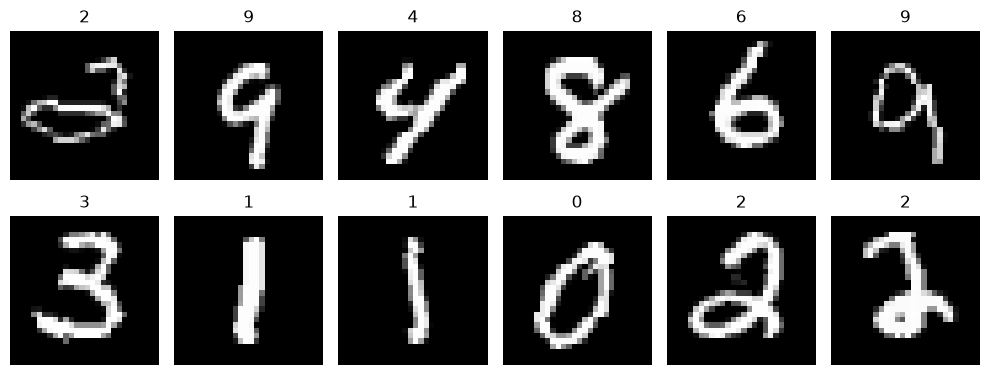

In [3]:
fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for ax, image, label in zip(axes.ravel(), images[:12], labels[:12]):
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(str(label.item()))
    ax.axis('off')
plt.tight_layout()

## Define a small CNN

The network uses two convolution blocks followed by a classifier head. Max pooling reduces spatial size after feature extraction.

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = SimpleCNN().to(device)
model

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

## Training utilities

We will reuse a compact training loop structure similar to the MLP notebook.

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * X_batch.size(0)
            total_correct += (logits.argmax(dim=1) == y_batch).sum().item()
            total_examples += X_batch.size(0)

    return total_loss / total_examples, total_correct / total_examples

## Train the CNN

For classroom use, a few epochs are enough to demonstrate the workflow. Increase `num_epochs` if you want a stronger model.

In [6]:
num_epochs = 5
history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(num_epochs):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    test_loss, test_acc = run_epoch(model, test_loader, criterion)

    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"train_loss={train_loss:.4f} | test_loss={test_loss:.4f} | "
        f"train_acc={train_acc:.3f} | test_acc={test_acc:.3f}"
    )

Epoch 1/5 | train_loss=0.2214 | test_loss=0.0439 | train_acc=0.931 | test_acc=0.986


Epoch 2/5 | train_loss=0.0774 | test_loss=0.0342 | train_acc=0.976 | test_acc=0.988


Epoch 3/5 | train_loss=0.0584 | test_loss=0.0308 | train_acc=0.982 | test_acc=0.990


Epoch 4/5 | train_loss=0.0503 | test_loss=0.0246 | train_acc=0.984 | test_acc=0.991


Epoch 5/5 | train_loss=0.0426 | test_loss=0.0229 | train_acc=0.987 | test_acc=0.993


## Plot learning curves

These plots summarize how optimization and accuracy changed over time.

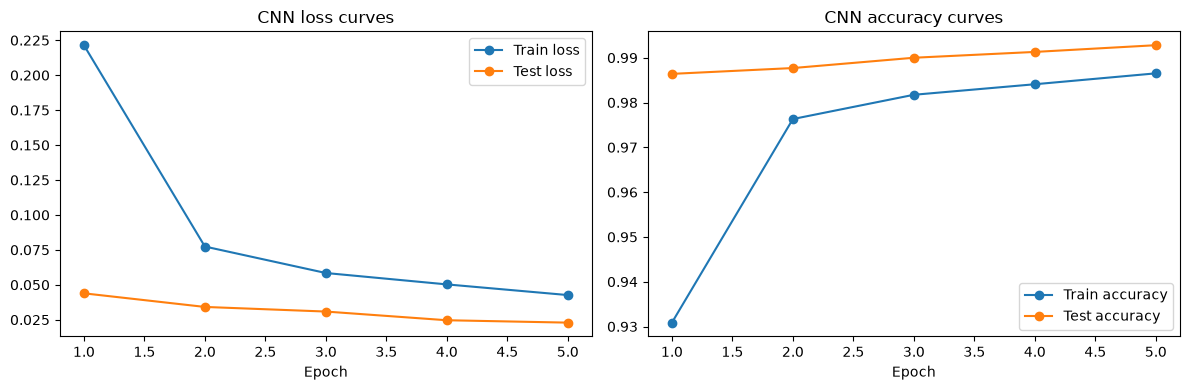

In [7]:
epochs = np.arange(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history['train_loss'], marker='o', label='Train loss')
axes[0].plot(epochs, history['test_loss'], marker='o', label='Test loss')
axes[0].set_title('CNN loss curves')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs, history['train_acc'], marker='o', label='Train accuracy')
axes[1].plot(epochs, history['test_acc'], marker='o', label='Test accuracy')
axes[1].set_title('CNN accuracy curves')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()

## Visualize predictions

Looking at individual predictions helps connect model metrics back to real images.

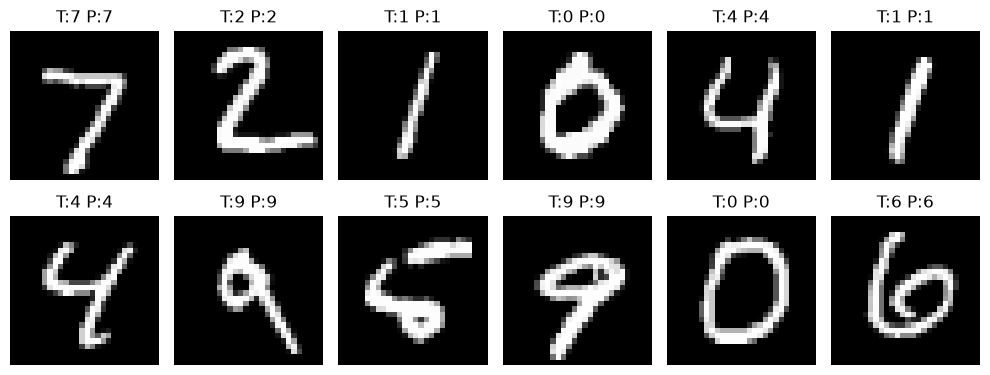

In [8]:
model.eval()
sample_images, sample_labels = next(iter(test_loader))
with torch.no_grad():
    sample_logits = model(sample_images.to(device))
    sample_preds = sample_logits.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for ax, image, truth, pred in zip(axes.ravel(), sample_images[:12], sample_labels[:12], sample_preds[:12]):
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f'T:{truth.item()} P:{pred.item()}')
    ax.axis('off')
plt.tight_layout()

## Transfer learning setup with ResNet18

MNIST is grayscale and small, while ResNet18 expects 3-channel images. We replicate the channel dimension, then hand the rest of the preprocessing to the weights themselves: every torchvision weight enum ships the exact resize/crop/normalization it was trained with as `weights.transforms()`. Deriving the transform from the weights — instead of hand-typing another model's normalization constants — is the same discipline as pinning the weights: the notebook records exactly what it used.

In [9]:
weights = models.ResNet18_Weights.IMAGENET1K_V1  # pinned explicitly, not DEFAULT
preprocess = weights.transforms()   # the preprocessing THESE weights were trained with
print(preprocess)

transfer_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    preprocess,
])

transfer_dataset = datasets.MNIST(root='data', train=True, download=True, transform=transfer_transform)
transfer_subset = Subset(transfer_dataset, list(range(512)))
transfer_loader = DataLoader(transfer_subset, batch_size=32, shuffle=True)

try:
    transfer_model = models.resnet18(weights=weights)
except Exception as exc:
    print('Falling back to randomly initialized ResNet18 because pretrained weights were unavailable:', exc)
    transfer_model = models.resnet18(weights=None)

for param in transfer_model.parameters():
    param.requires_grad = False

transfer_model.fc = nn.Linear(transfer_model.fc.in_features, 10)
transfer_model = transfer_model.to(device)
transfer_model

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

## Run a short head-only fine-tuning pass

The next cell trains only the new classification head for one epoch on a tiny subset. This keeps the notebook lightweight while still demonstrating the transfer learning workflow.

In [10]:
transfer_criterion = nn.CrossEntropyLoss()
transfer_optimizer = torch.optim.Adam(transfer_model.fc.parameters(), lr=1e-3)

transfer_model.train()
total_loss = 0.0
total_correct = 0
total_examples = 0

for X_batch, y_batch in transfer_loader:
    X_batch = X_batch.to(device)
    y_batch = y_batch.to(device)

    transfer_optimizer.zero_grad()
    logits = transfer_model(X_batch)
    loss = transfer_criterion(logits, y_batch)
    loss.backward()
    transfer_optimizer.step()

    total_loss += loss.item() * X_batch.size(0)
    total_correct += (logits.argmax(dim=1) == y_batch).sum().item()
    total_examples += X_batch.size(0)

print('Transfer subset loss:', total_loss / total_examples)
print('Transfer subset accuracy:', total_correct / total_examples)

Transfer subset loss: 2.131640262901783
Transfer subset accuracy: 0.255859375


## Wrap-up

You trained a custom CNN, plotted learning curves, and adapted a pretrained ResNet18 for a new classification task. In practice, transfer learning often delivers strong results when you have limited labeled data.